# Exploratory Data Analysis

This notebook performs a basic exploratory data analysis on the diabetes dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_theme(style="whitegrid")

# Load the data
df = pd.read_csv('data/train.csv')

# Pre-processing: Identify numeric and categorical columns
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
categorical_v2 = df.select_dtypes(include=['object']).columns.tolist()

# Include numeric columns with low cardinality as categorical (e.g., alcohol consumption, history flags)
threshold = 10
pseudo_categorical = [col for col in numeric_cols if df[col].nunique() <= threshold and col != 'id']
categorical_cols = list(set(categorical_v2 + pseudo_categorical))

df.head()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,...,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.0
1,1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,...,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.0
2,2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,...,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0
3,3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,...,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.0
4,4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,...,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.0


## Tabulating Missing Values

In [2]:
missing_values = df.isnull().sum()
missing_values_df = pd.DataFrame({'Missing Values': missing_values, 'Percentage': (missing_values / len(df)) * 100})
missing_values_df

,Missing Values,Percentage
id,0,0.0
age,0,0.0
alcohol_consumption_per_week,0,0.0
physical_activity_minutes_per_week,0,0.0
diet_score,0,0.0
sleep_hours_per_day,0,0.0
screen_time_hours_per_day,0,0.0
bmi,0,0.0
waist_to_hip_ratio,0,0.0
systolic_bp,0,0.0


## Summary Statistics: Maximum/Minimum for Numeric Variables

In [3]:
stats_df = df[numeric_cols].describe().loc[['min', 'max']]
stats_df.T

,min,max
id,0.00,699999.00
age,19.00,89.00
alcohol_consumption_per_week,1.00,9.00
physical_activity_minutes_per_week,1.00,747.00
diet_score,0.10,9.90
sleep_hours_per_day,3.10,9.90
screen_time_hours_per_day,0.60,16.50
bmi,15.10,38.40
waist_to_hip_ratio,0.68,1.05
systolic_bp,91.00,163.00


## Tally of Unique Values for Numeric Variables

In [4]:
unique_counts = df[numeric_cols].nunique().sort_values(ascending=False)
unique_counts_df = pd.DataFrame({'Unique Values': unique_counts})
unique_counts_df

,Unique Values
id,700000
physical_activity_minutes_per_week,565
bmi,231
triglycerides,228
cholesterol_total,154
screen_time_hours_per_day,151
ldl_cholesterol,151
diet_score,99
systolic_bp,71
age,71


## Tally of Unique Values for Categorical Variables
Note: Includes numeric columns with low cardinality (e.g., alcohol consumption, history flags).

In [5]:
cat_unique_counts = df[categorical_cols].nunique().sort_values(ascending=False)
cat_unique_counts_df = pd.DataFrame({'Unique Values': cat_unique_counts})
cat_unique_counts_df

,Unique Values
alcohol_consumption_per_week,9
ethnicity,5
income_level,5
employment_status,4
education_level,4
gender,3
smoking_status,3
cardiovascular_history,2
family_history_diabetes,2
diagnosed_diabetes,2


## Histograms of Numeric Variables

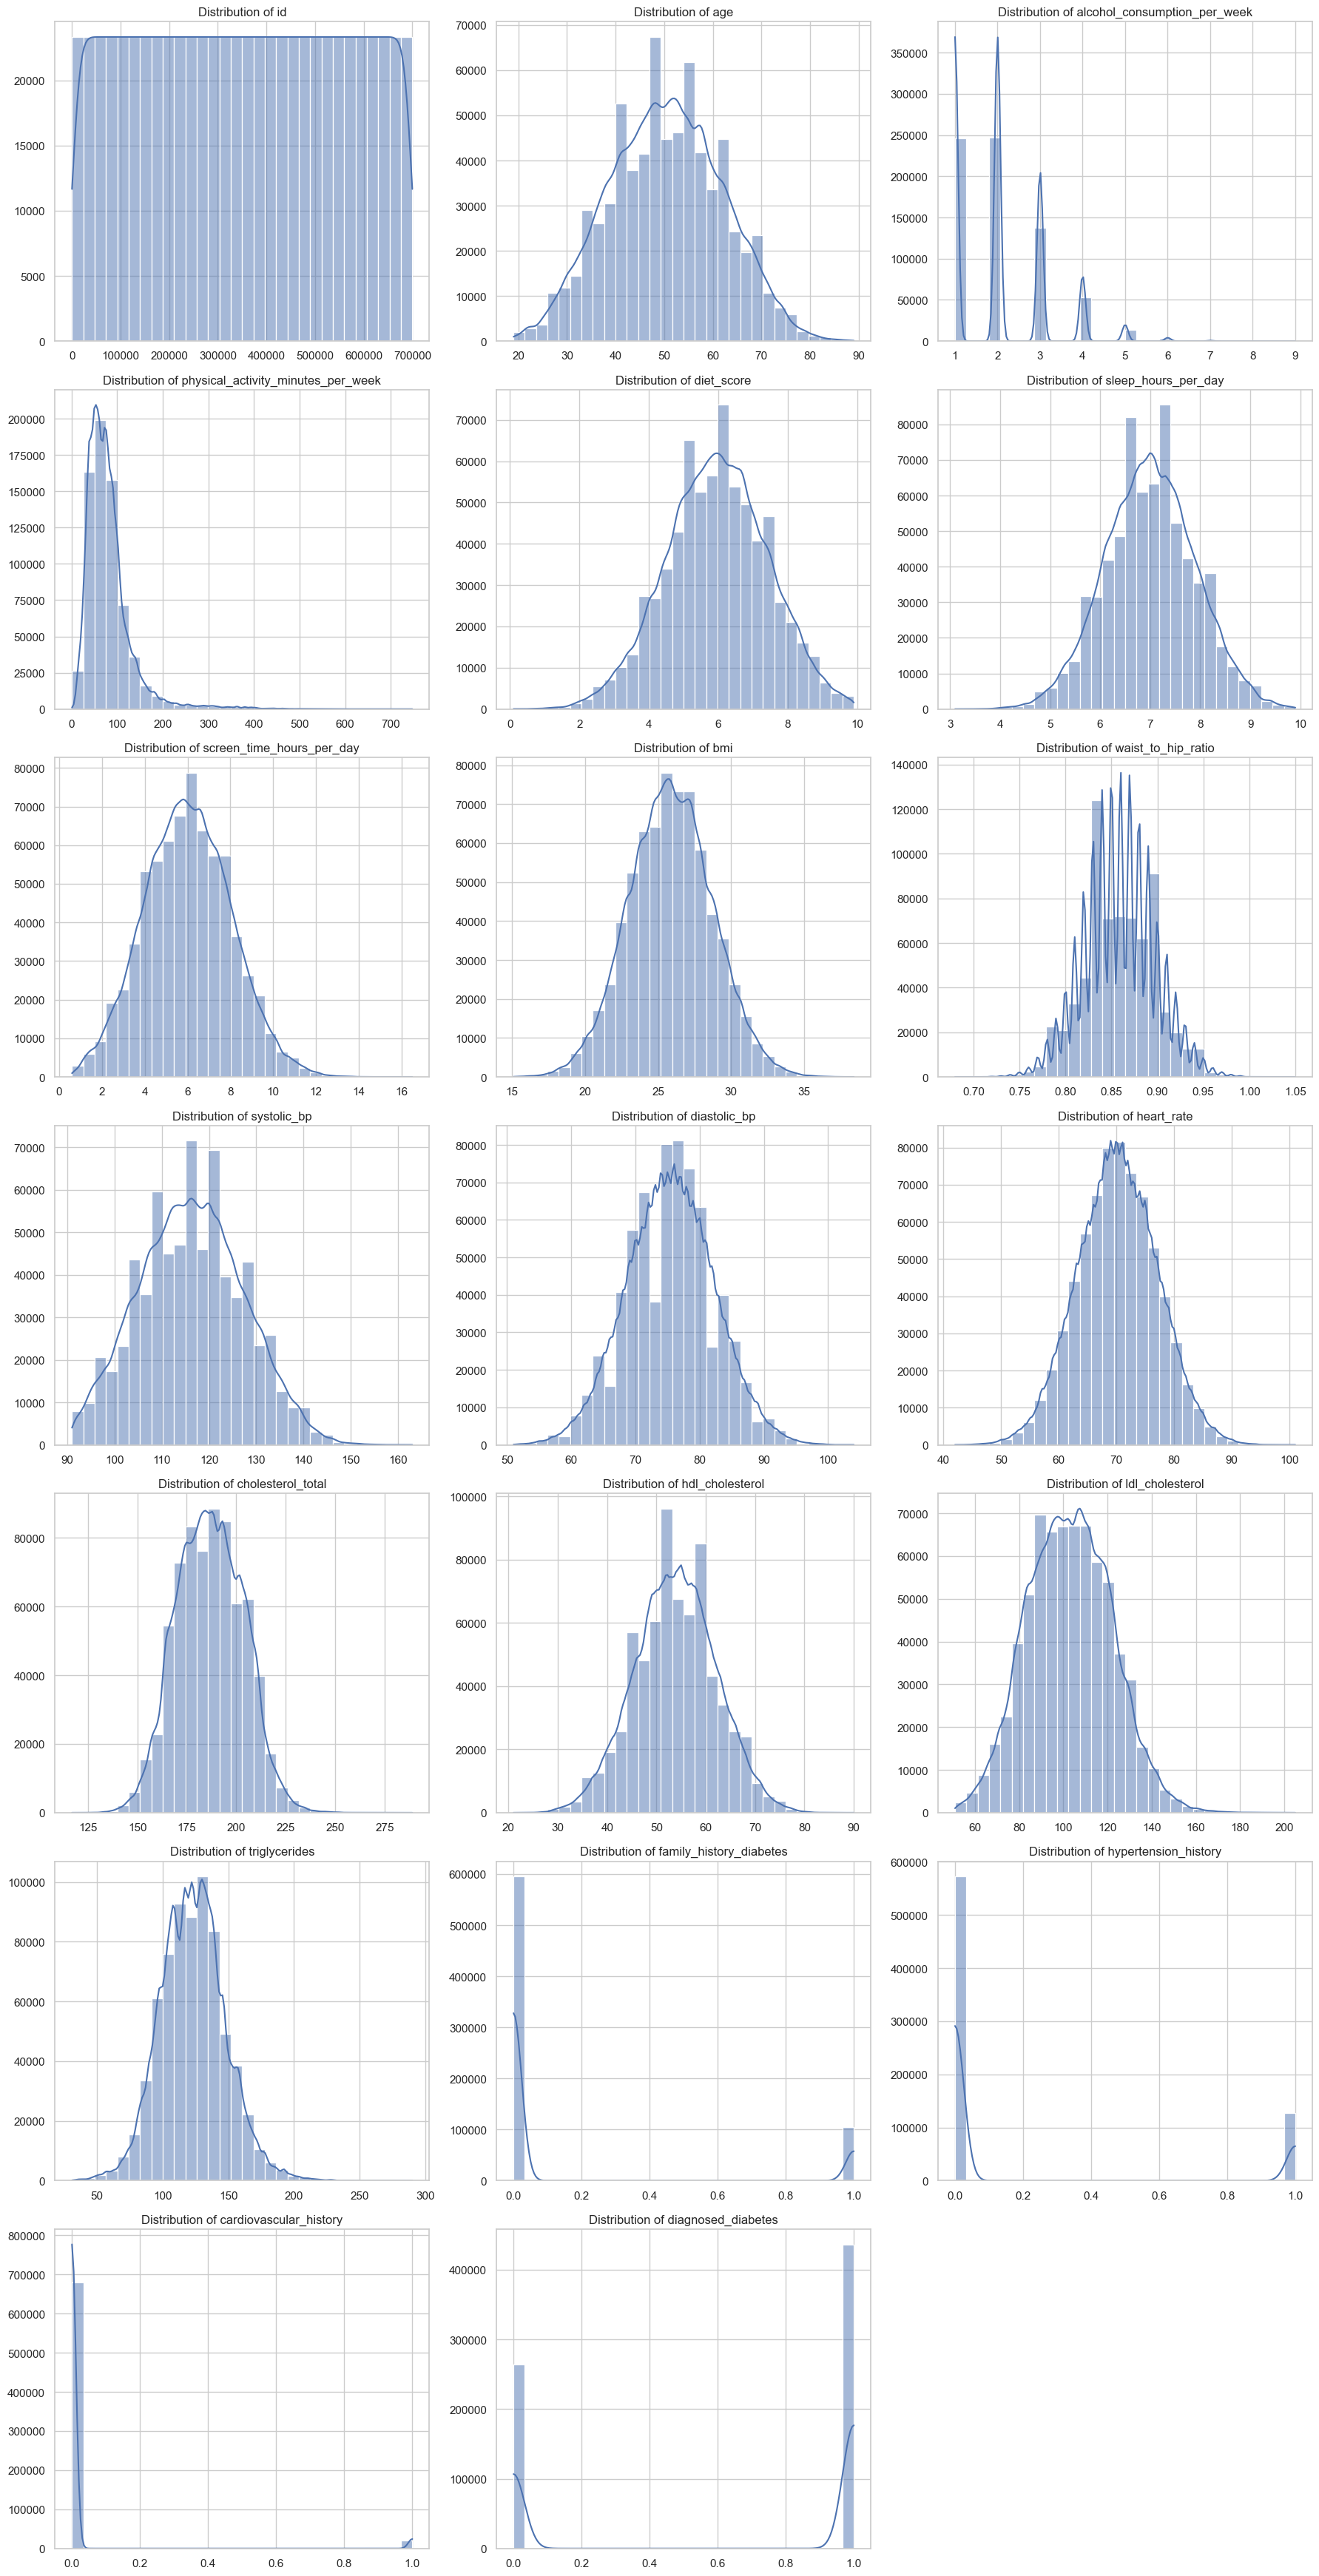

In [6]:
# Plot histograms for numeric variables
num_features = len(numeric_cols)
cols = 3
rows = (num_features + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], bins=30)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Analyze individual columns

--------------------------------------------------

Analyzing Column: id
Type: int64
Unique values: 700000
-> Classification: Genuine Numeric
Min: 0.0
Max: 699999.0
Mean: 349999.5
Median: 349999.5
SD: 202072.73855388476


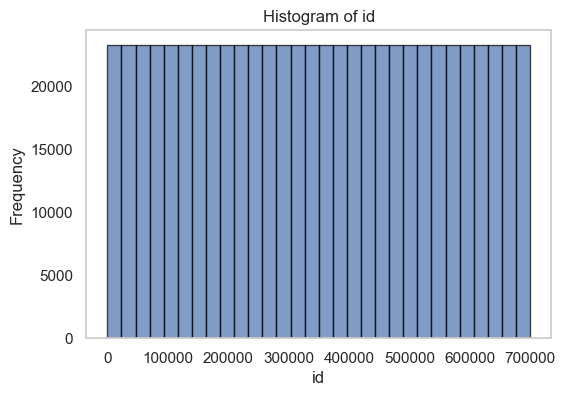

--------------------------------------------------

Analyzing Column: age
Type: int64
Unique values: 71
-> Classification: Genuine Numeric
Min: 19.0
Max: 89.0
Mean: 50.35973428571429
Median: 50.0
SD: 11.655520318209188


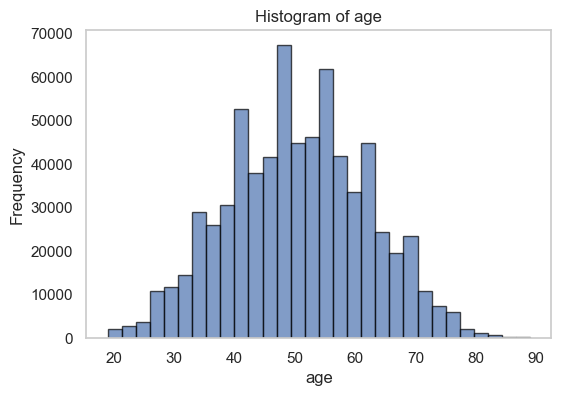

--------------------------------------------------

Analyzing Column: alcohol_consumption_per_week
Type: int64
Unique values: 9
-> Classification: Ordinal / Categorical
                               Count  Percentage
alcohol_consumption_per_week                    
2                             246592   35.227429
1                             246311   35.187286
3                             137565   19.652143
4                              52973    7.567571
5                              13322    1.903143
6                               2728    0.389714
7                                447    0.063857
8                                 59    0.008429
9                                  3    0.000429
--------------------------------------------------

Analyzing Column: physical_activity_minutes_per_week
Type: int64
Unique values: 565
-> Classification: Genuine Numeric
Min: 1.0
Max: 747.0
Mean: 80.23080285714286
Median: 71.0
SD: 51.19507054902905


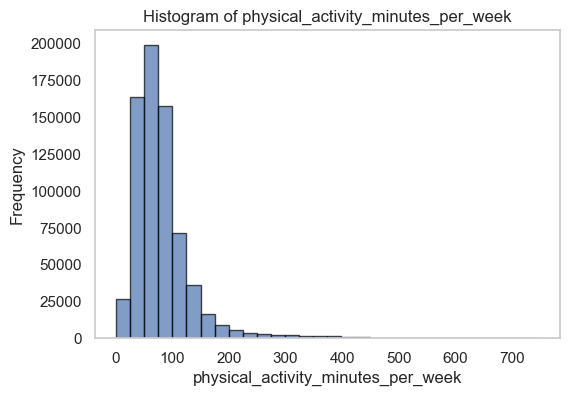

--------------------------------------------------

Analyzing Column: diet_score
Type: float64
Unique values: 99
-> Classification: Genuine Numeric
Min: 0.1
Max: 9.9
Mean: 5.963694714285714
Median: 6.0
SD: 1.4633364907996715


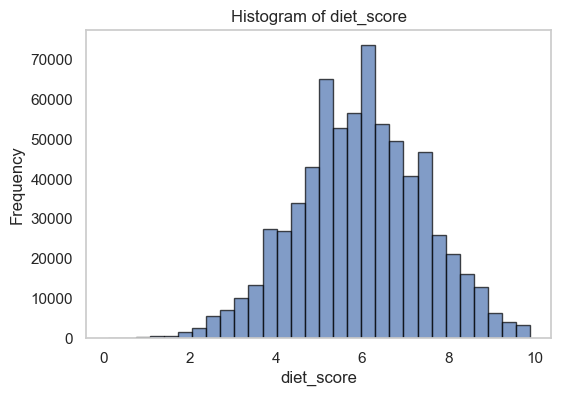

--------------------------------------------------

Analyzing Column: sleep_hours_per_day
Type: float64
Unique values: 69
-> Classification: Genuine Numeric
Min: 3.1
Max: 9.9
Mean: 7.002199714285715
Median: 7.0
SD: 0.9019068421294129


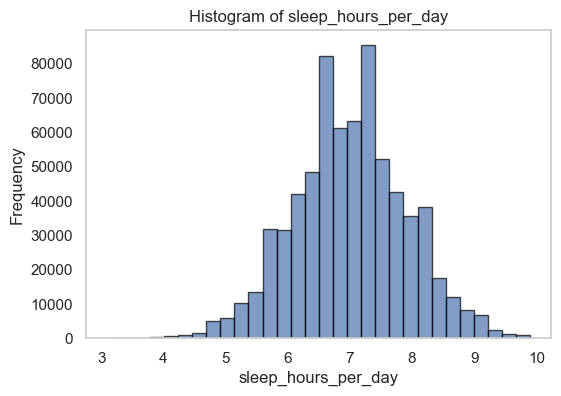

--------------------------------------------------

Analyzing Column: screen_time_hours_per_day
Type: float64
Unique values: 151
-> Classification: Genuine Numeric
Min: 0.6
Max: 16.5
Mean: 6.012733
Median: 6.0
SD: 2.0227074538997565


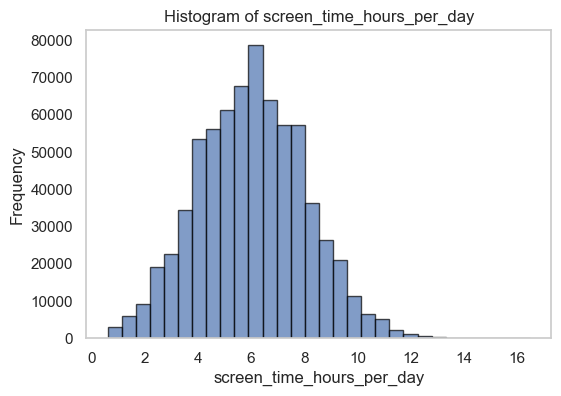

--------------------------------------------------

Analyzing Column: bmi
Type: float64
Unique values: 231
-> Classification: Genuine Numeric
Min: 15.1
Max: 38.4
Mean: 25.874683899999994
Median: 25.9
SD: 2.8607046622136694


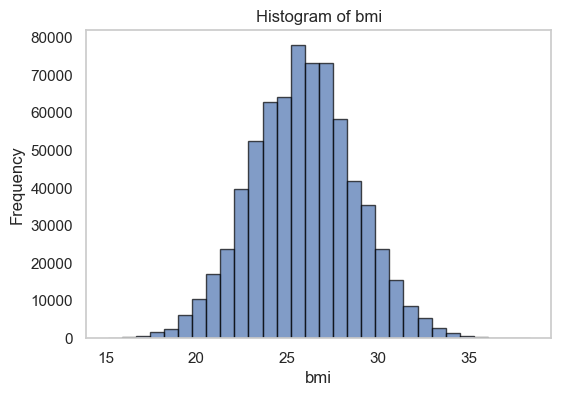

--------------------------------------------------

Analyzing Column: waist_to_hip_ratio
Type: float64
Unique values: 36
-> Classification: Genuine Numeric
Min: 0.68
Max: 1.05
Mean: 0.8587658857142857
Median: 0.86
SD: 0.03797986902522569


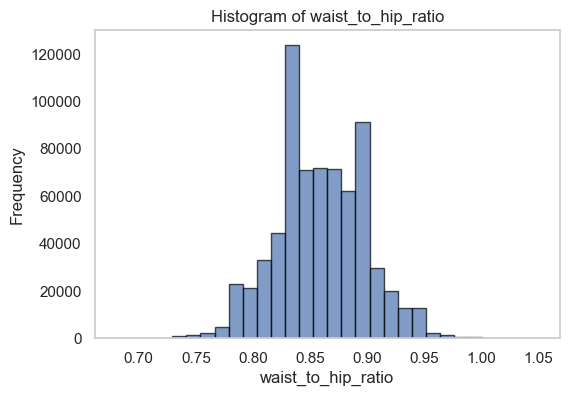

--------------------------------------------------

Analyzing Column: systolic_bp
Type: int64
Unique values: 71
-> Classification: Genuine Numeric
Min: 91.0
Max: 163.0
Mean: 116.29419285714286
Median: 116.0
SD: 11.01039000364476


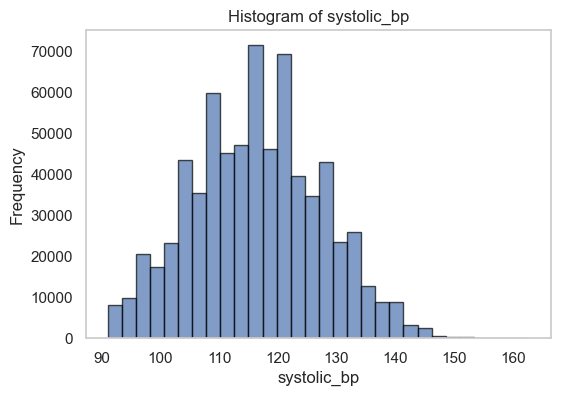

--------------------------------------------------

Analyzing Column: diastolic_bp
Type: int64
Unique values: 54
-> Classification: Genuine Numeric
Min: 51.0
Max: 104.0
Mean: 75.44092428571429
Median: 75.0
SD: 6.825774852214789


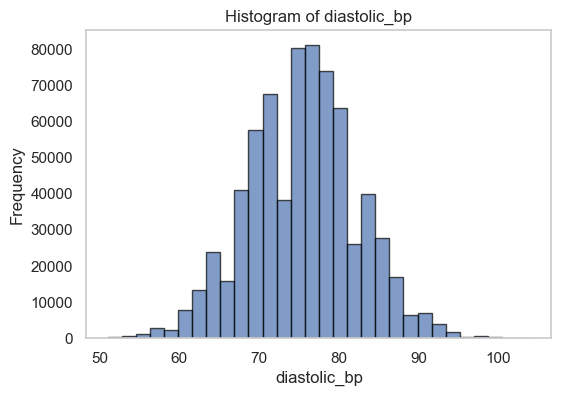

--------------------------------------------------

Analyzing Column: heart_rate
Type: int64
Unique values: 60
-> Classification: Genuine Numeric
Min: 42.0
Max: 101.0
Mean: 70.16774857142858
Median: 70.0
SD: 6.938722241122631


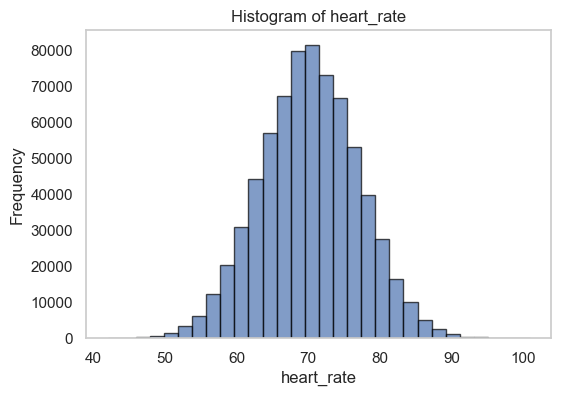

--------------------------------------------------

Analyzing Column: cholesterol_total
Type: int64
Unique values: 154
-> Classification: Genuine Numeric
Min: 117.0
Max: 289.0
Mean: 186.81880142857142
Median: 187.0
SD: 16.730831841463605


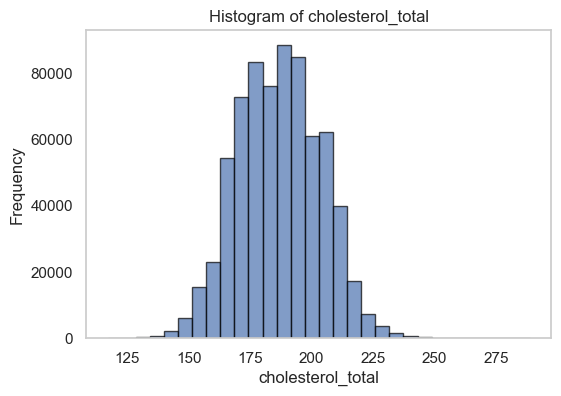

--------------------------------------------------

Analyzing Column: hdl_cholesterol
Type: int64
Unique values: 69
-> Classification: Genuine Numeric
Min: 21.0
Max: 90.0
Mean: 53.823214285714286
Median: 54.0
SD: 8.266545236556743


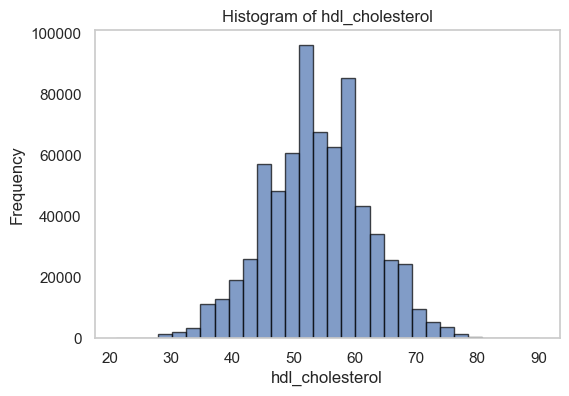

--------------------------------------------------

Analyzing Column: ldl_cholesterol
Type: int64
Unique values: 151
-> Classification: Genuine Numeric
Min: 51.0
Max: 205.0
Mean: 102.90585428571428
Median: 103.0
SD: 19.022415854588957


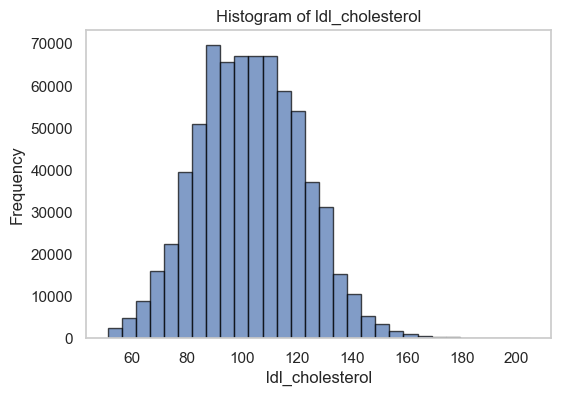

--------------------------------------------------

Analyzing Column: triglycerides
Type: int64
Unique values: 228
-> Classification: Genuine Numeric
Min: 31.0
Max: 290.0
Mean: 123.08185
Median: 123.0
SD: 24.73939684684579


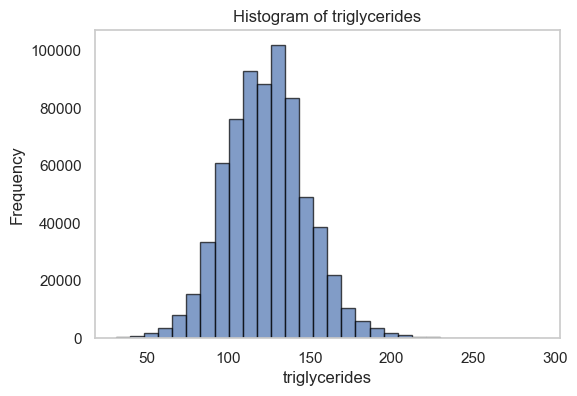

--------------------------------------------------

Analyzing Column: gender
Type: object
Unique values: 3
-> Classification: Ordinal / Categorical
         Count  Percentage
gender                    
Female  363237   51.891000
Male    333085   47.583571
Other     3678    0.525429
--------------------------------------------------

Analyzing Column: ethnicity
Type: object
Unique values: 5
-> Classification: Ordinal / Categorical
            Count  Percentage
ethnicity                    
White      386153   55.164714
Hispanic   129984   18.569143
Black      106301   15.185857
Asian       60120    8.588571
Other       17442    2.491714
--------------------------------------------------

Analyzing Column: education_level
Type: object
Unique values: 4
-> Classification: Ordinal / Categorical
                  Count  Percentage
education_level                    
Highschool       344145   49.163571
Graduate         261268   37.324000
Postgraduate      79642   11.377429
No formal         1

In [7]:
# Analysis of columns based on unique value count
for col in df.columns:
    print("-" * 50)
    print(f"\nAnalyzing Column: {col}")
    print(f"Type: {df[col].dtype}")
    n_unique = df[col].nunique()
    print(f"Unique values: {n_unique}")
    
    if n_unique > 10:
        print("-> Classification: Genuine Numeric")
        # Statistics
        desc = df[col].describe()
        print(f"Min: {desc['min']}")
        print(f"Max: {desc['max']}")
        print(f"Mean: {desc['mean']}")
        print(f"Median: {df[col].median()}")
        print(f"SD: {desc['std']}")
        
        # Histogram
        plt.figure(figsize=(6, 4))
        df[col].hist(bins=30, edgecolor='black', alpha=0.7)
        plt.title(f"Histogram of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.grid(False)
        plt.show()
    else:
        print("-> Classification: Ordinal / Categorical")
        # Counts and Percentages
        counts = df[col].value_counts()
        percentages = df[col].value_counts(normalize=True) * 100
        summary_df = pd.DataFrame({'Count': counts, 'Percentage': percentages})
        print(summary_df)


## Correlation Analysis: Scatter Plots

Here we visualize the relationship between variables that are often correlated in health datasets, such as blood pressure components, obesity metrics, and lipid levels. We use a random sample of points to avoid overplotting.

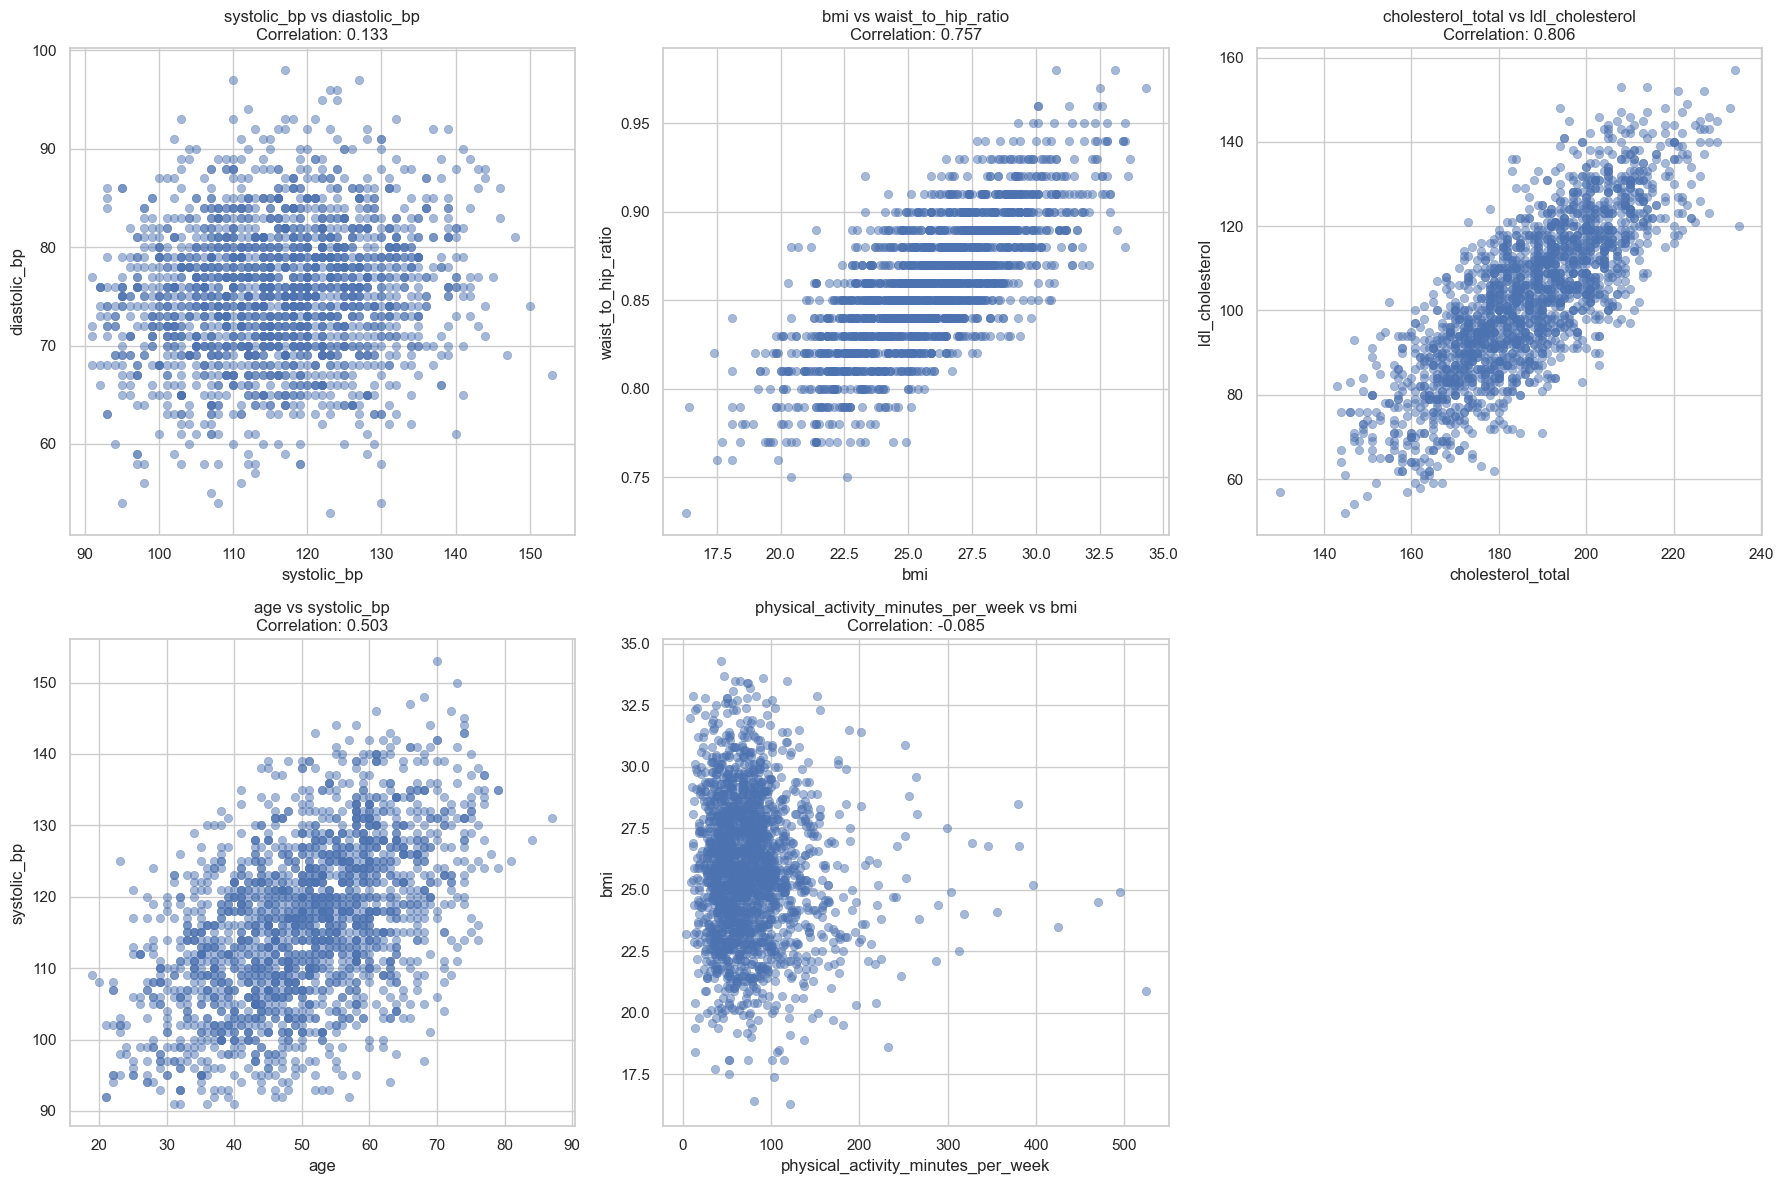

In [8]:
# Define pairs of variables to inspect
pairs = [
    ('systolic_bp', 'diastolic_bp'),
    ('bmi', 'waist_to_hip_ratio'),
    ('cholesterol_total', 'ldl_cholesterol'),
    ('age', 'systolic_bp'),
    ('physical_activity_minutes_per_week', 'bmi')
]

plt.figure(figsize=(18, 12))

plot_count = 0
for x_col, y_col in pairs:
    if x_col in df.columns and y_col in df.columns:
        plot_count += 1
        plt.subplot(2, 3, plot_count)
        
        # Downsample for clearer scatter plots if dataset is large (e.g. > 2000 points)
        if len(df) > 2000:
            plot_data = df.sample(2000, random_state=42)
        else:
            plot_data = df
            
        sns.scatterplot(data=plot_data, x=x_col, y=y_col, alpha=0.5, edgecolor=None)
        
        # Calculate correlation on full dataset
        corr = df[x_col].corr(df[y_col])
        plt.title(f'{x_col} vs {y_col}\nCorrelation: {corr:.3f}')

plt.tight_layout()
plt.show()

## Feature Correlation with Target (diagnosed_diabetes)

In this section, we analyze the relationship between each feature and the target variable `diagnosed_diabetes`. 
We calculate the Pearson correlation coefficient and the linear regression slope for each numeric feature (excluding `id`).

Feature                             | Correlation  | LinReg Slope | P-Value     
-------------------------------------------------------------------------------------
family_history_diabetes             | 0.2111       | 0.286894     | 0.0000e+00
physical_activity_minutes_per_week  | -0.1698      | -0.001607    | 0.0000e+00
age                                 | 0.1612       | 0.006700     | 0.0000e+00
systolic_bp                         | 0.1071       | 0.004715     | 0.0000e+00
bmi                                 | 0.1056       | 0.017884     | 0.0000e+00
ldl_cholesterol                     | 0.1028       | 0.002618     | 0.0000e+00
triglycerides                       | 0.0906       | 0.001775     | 0.0000e+00
cholesterol_total                   | 0.0881       | 0.002552     | 0.0000e+00
waist_to_hip_ratio                  | 0.0810       | 1.034063     | 0.0000e+00
hdl_cholesterol                     | -0.0532      | -0.003120    | 0.0000e+00
diet_score                          | -0.05

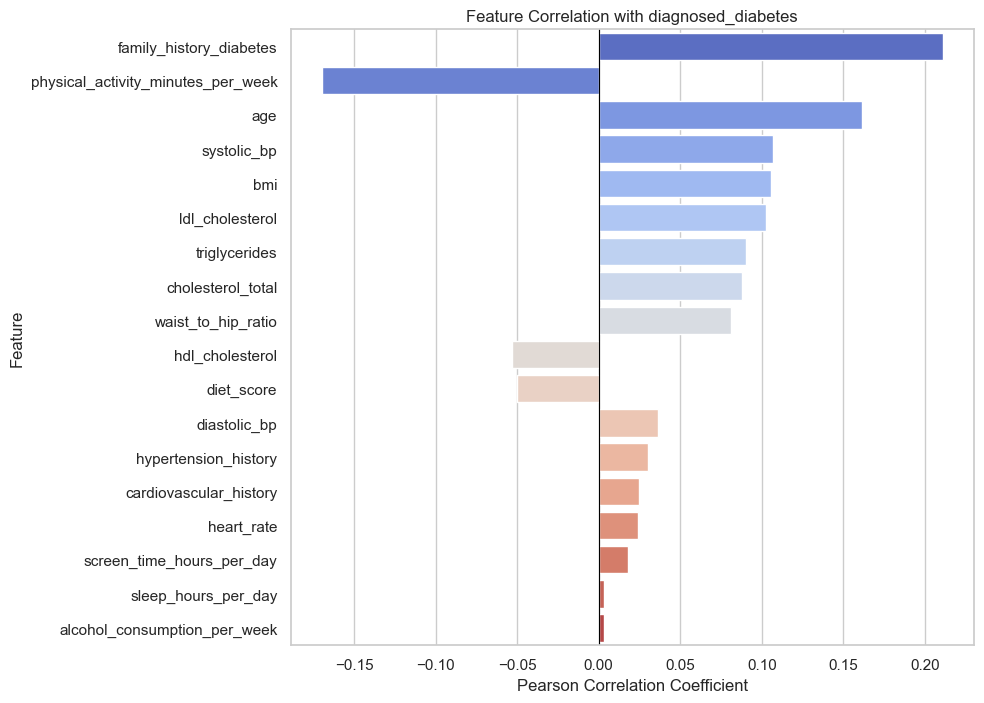

In [10]:
from scipy import stats

target = 'diagnosed_diabetes'
feature_cols = [c for c in df.select_dtypes(include=['number']).columns if c != 'id' and c != target]

print(f"{'Feature':<35} | {'Correlation':<12} | {'LinReg Slope':<12} | {'P-Value':<12}")
print("-" * 85)

results = []
for col in feature_cols:
    # Drop NaNs for valid comparison
    valid_data = df[[col, target]].dropna()
    if len(valid_data) > 1:
        slope, intercept, r_value, p_value, std_err = stats.linregress(valid_data[col], valid_data[target])
        results.append({
            'Feature': col,
            'Correlation': r_value,
            'Slope': slope,
            'P-Value': p_value
        })

# Sort by absolute correlation strength
results.sort(key=lambda x: abs(x['Correlation']), reverse=True)

for res in results:
    print(f"{res['Feature']:<35} | {res['Correlation']:<12.4f} | {res['Slope']:<12.6f} | {res['P-Value']:.4e}")

# Visualize correlations
results_df = pd.DataFrame(results)
plt.figure(figsize=(10, len(results_df) * 0.4))
sns.barplot(data=results_df, x='Correlation', y='Feature', hue='Feature', palette='coolwarm', legend=False)
plt.title(f'Feature Correlation with {target}')
plt.xlabel('Pearson Correlation Coefficient')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()